# Clasificación de sentimiento: EDA (Análisis exploratorio de los datos) 
En esta celda, vamos a visualizar los datos de nuestro dataset artificial para crear un modelo de NLP que clasifique el prompt introducido por el usuario en 4 categorías:
- Inaceptable
- Alto riesgo
- Riesgo limitado
- Riesgo mínimo

Esto es un ejercicio similar al análisis de sentimiento que hemos realizado durante el módulo, pero en este caso, se conoce como text classification supervisada multiclase, no sentiment analysis. 


In [1]:
#Al principio de cada notebook, añadimos estas líneas para que se recarguen automáticamente las funciones que hayamos editado en el módulo functions.py sin tener que reiniciar el kernel cada vez.
%load_ext autoreload
%autoreload 2

## Carga del dataset 
Cargamos el dataset y lo guardamos en archivos separados 

In [2]:
# Abrimos el dataset
import pandas as pd
path = "datasets/dataset_riesgo.csv"
df = pd.read_csv(path)
# Separamos las características (X) y la variable objetivo (y)
X = df["descripcion"]
y = df["etiqueta"]


# Imprimimos las formas de los conjuntos de entrenamiento y prueba
print("Conjunto:", X.shape, y.shape)


Conjunto: (300,) (300,)


# Primer acercamiento a los datos: 

1. Verificaciones básicas
Objetivo: confirmar que no hay nulos ni clases desbalanceadas.
2. Comprobar duplicados
3. Longitud de los textos
4. Limpieza mínima del texto
5. Generación de un word cloud para comprobar las palabras más utilizadas 

In [3]:
#Comprobamos si nuestro dataset tenía duplicados antes de la división
df.duplicated().sum()

np.int64(0)

In [4]:
# Mostramos las primeras filas del conjunto de entrenamiento
X.head()
# Mostramos las últimas filas del conjunto de entrenamiento
X.tail()


295    Sistema de optimización de la iluminación en m...
296    Herramienta de análisis de biodiversidad marin...
297    Sistema de generación automática de recetas de...
298    Herramienta de análisis de contratos de sumini...
299    Sistema de monitorización del estado de equipo...
Name: descripcion, dtype: object

In [5]:
# Mostramos las últimas filas del conjunto de entrenamiento
y.head()
# mostramos las últimas filas del conjunto de entrenamiento
y.tail()

295    riesgo_minimo
296    riesgo_minimo
297    riesgo_minimo
298    riesgo_minimo
299    riesgo_minimo
Name: etiqueta, dtype: object

<Axes: xlabel='etiqueta'>

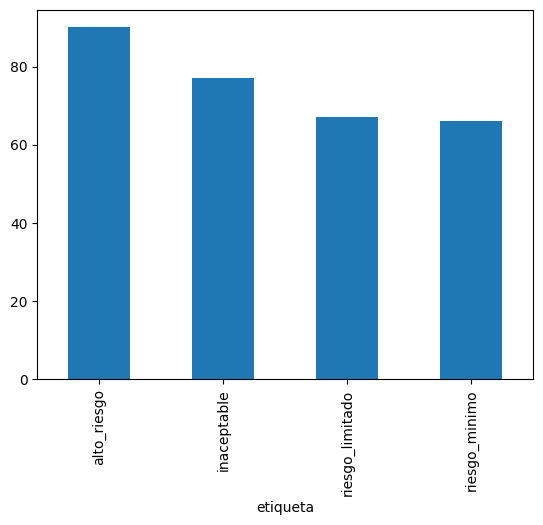

In [6]:
# Comprobamos la distribución de las etiquetas en el conjunto de entrenamiento
df['etiqueta'].value_counts().sort_index().plot(kind='bar')

# 1️ Distribución de clases:
Como vemos en el gráfico anterior, el dataset está bastante equilibrado:
- alto_riesgo ≈ 90
- inaceptable ≈ 77
- riesgo_limitado ≈ 67
- riesgo_minimo ≈ 66


In [7]:
# Analizamos la longitud de las descripciones para ver si hay alguna diferencia entre las clases
df["longitud"] = df["descripcion"].apply(len)
df["longitud"].describe()

count    300.000000
mean     186.453333
std       17.869683
min      143.000000
25%      175.000000
50%      186.000000
75%      198.250000
max      238.000000
Name: longitud, dtype: float64

In [8]:
# Comprobamos el tamaño del vocabulario bruto
raw_vocab = set(" ".join(df['descripcion']).split())
len(raw_vocab)

1992

In [9]:
#Creamos una nueva columna con el texto limpio
from functions import limpiar_texto

df["descripcion_limpia"] = df["descripcion"].apply(limpiar_texto)

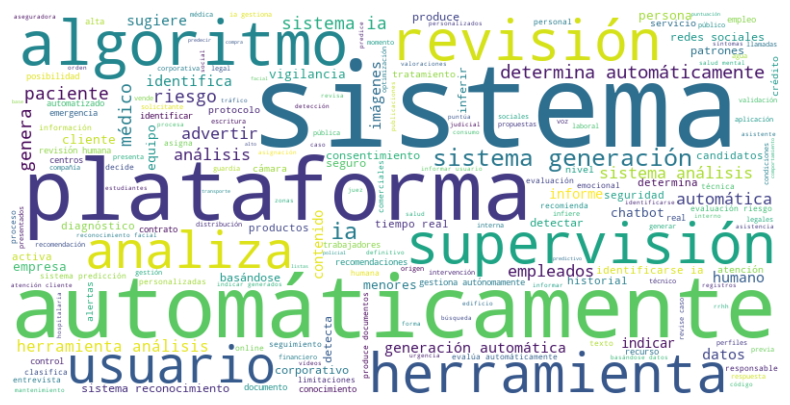

In [10]:
#Creamos un wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# Unimos todas las descripciones limpias en un solo texto
texto_completo = " ".join(df["descripcion_limpia"])
# Creamos el wordcloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(texto_completo)
# Mostramos el wordcloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

# Wordcloud
Palabras dominantes:
- sistema
- algoritmo
- automáticamente
- supervisión
- revisión
- herramienta
- usuario
- biométrica
- reconocimiento
- Interpretación:

El dataset gira alrededor de cuatro ejes claros:

- Automatización
- Supervisión humana
- Identificación biométrica
- Impacto sobre personas

Eso encaja perfectamente con el AI Act.


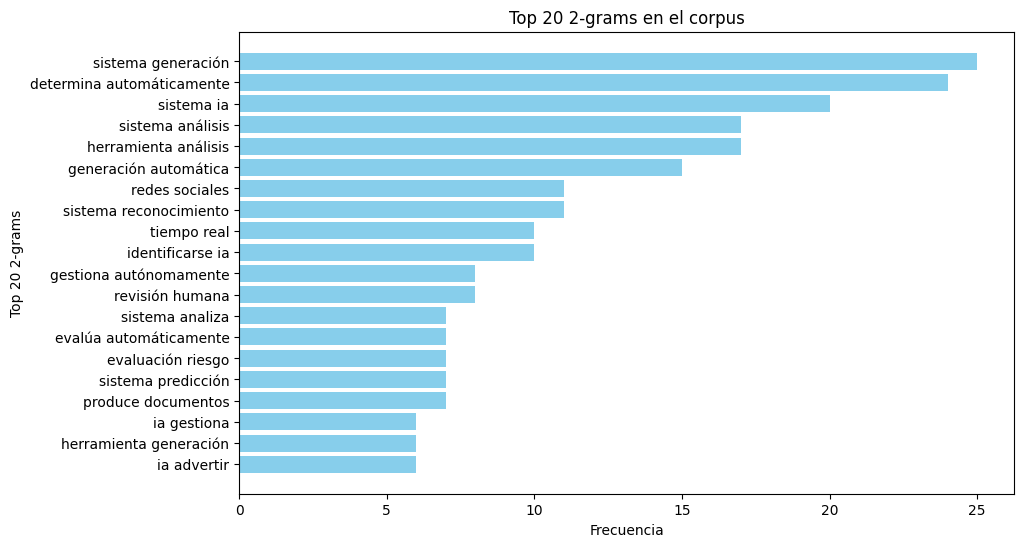

[('sistema generación', 25), ('determina automáticamente', 24), ('sistema ia', 20), ('sistema análisis', 17), ('herramienta análisis', 17), ('generación automática', 15), ('redes sociales', 11), ('sistema reconocimiento', 11), ('tiempo real', 10), ('identificarse ia', 10), ('gestiona autónomamente', 8), ('revisión humana', 8), ('sistema analiza', 7), ('evalúa automáticamente', 7), ('evaluación riesgo', 7), ('sistema predicción', 7), ('produce documentos', 7), ('ia gestiona', 6), ('herramienta generación', 6), ('ia advertir', 6)]


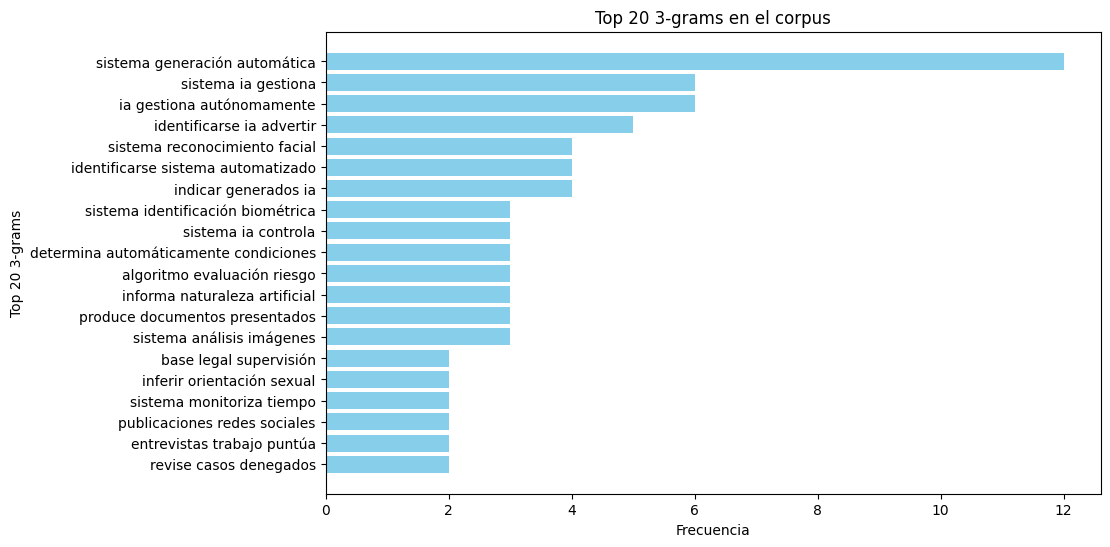

[('sistema generación automática', 12), ('sistema ia gestiona', 6), ('ia gestiona autónomamente', 6), ('identificarse ia advertir', 5), ('sistema reconocimiento facial', 4), ('identificarse sistema automatizado', 4), ('indicar generados ia', 4), ('sistema identificación biométrica', 3), ('sistema ia controla', 3), ('determina automáticamente condiciones', 3), ('algoritmo evaluación riesgo', 3), ('informa naturaleza artificial', 3), ('produce documentos presentados', 3), ('sistema análisis imágenes', 3), ('base legal supervisión', 2), ('inferir orientación sexual', 2), ('sistema monitoriza tiempo', 2), ('publicaciones redes sociales', 2), ('entrevistas trabajo puntúa', 2), ('revise casos denegados', 2)]


In [11]:
#Comprobamos los n-gramas más comunes
from functions import top_ngrams
print(top_ngrams(df, n=20, ngram=2))
print(top_ngrams(df, n=20, ngram=3))

# N-grams (2 y 3)
Ahora el corpus refleja señal semántica real:
Aparecen patrones como:
- “determina automáticamente”
- “revisión humana”
- “identificación biométrica”
- “reconocimiento facial”
- “evaluación riesgo”
- “tiempo real”
- “genera automáticamente”
Conclusión:
El texto contiene vocabulario discriminativo.
El modelo puede aprender reglas regulatorias reales.
La limpieza eliminó bastante ruido estructural.

# Conclusiones del análisis exploratorio: 
(En este caso, recopilo todo lo comprendido anteriormente y añado algunas ideas más que surgen después de tener visión del conjunto)
 1️ Distribución de clases
El dataset está bastante equilibrado:
- alto_riesgo ≈ 90
- inaceptable ≈ 77
- riesgo_limitado ≈ 67
- riesgo_minimo ≈ 66

2️ N-grams (2 y 3)
Ahora el corpus refleja señal semántica real:
Aparecen patrones como:
- “determina automáticamente”
- “revisión humana”
- “identificación biométrica”
- “reconocimiento facial”
- “evaluación riesgo”
- “tiempo real”
- “genera automáticamente”

Conclusión:
El texto contiene vocabulario discriminativo.
El modelo puede aprender reglas regulatorias reales.
La limpieza eliminó bastante ruido estructural.

3️ Wordcloud
Palabras dominantes:
- sistema
- algoritmo
- automáticamente
- supervisión
- revisión
- herramienta
- usuario
- biométrica
- reconocimiento
- Interpretación:

El dataset gira alrededor de cuatro ejes claros:

- Automatización
- Supervisión humana
- Identificación biométrica
- Impacto sobre personas

Eso encaja perfectamente con el AI Act.

4️ Riesgo potencial detectado
Aún hay redacción relativamente homogénea:
Muchos textos empiezan por:
- “sistema…”
- “algoritmo…”
- “herramienta…”

Riesgo:
El modelo puede aprender patrones editoriales además de patrones legales.
No es crítico ahora, pero a futuro conviene introducir variabilidad lingüística.

5️ Señales fuertes que el modelo puede usar
- Muy probablemente el clasificador aprende asociaciones como:
- biométrico + tiempo real → inaceptable
- revisión humana → riesgo limitado
- determina automáticamente → alto riesgo
- advertir / identificar como IA → limitado
- consentimiento / vulnerabilidad → inaceptable
- Eso es coherente con la regulación.

6️ Conclusión general del EDA

Nuestro dataset, generado artificialmente utilizando IA:

- Está bien balanceado
- Tiene vocabulario regulatorio claro
- Tiene patrones discriminativos útiles
- Es adecuado para ML clásico
- Es suficientemente rico para intentar fine-tuning después

Debilidad principal:
Homogeneidad estilística.

In [12]:
# Guardamos el dataset limpio para usarlo en el siguiente notebook
df.to_csv("datasets/dataset_riesgo_limpio.csv", index=False)


In [13]:
# ── MLflow (solo falla esta celda si el servidor no está disponible) ──
from functions import log_mlflow_safe

dist = df["etiqueta"].value_counts()

try:
    log_mlflow_safe(
        run_name="eda",
        params={
            "n_samples": len(df),
            "n_clases": df["etiqueta"].nunique(),
            "text_column": "descripcion",
            "raw_vocab_size": len(set(" ".join(df["descripcion"]).split())),
        },
        metrics={
            "n_alto_riesgo":     int(dist.get("alto_riesgo", 0)),
            "n_inaceptable":     int(dist.get("inaceptable", 0)),
            "n_riesgo_limitado": int(dist.get("riesgo_limitado", 0)),
            "n_riesgo_minimo":   int(dist.get("riesgo_minimo", 0)),
            "longitud_media":    round(df["longitud"].mean(), 2),
            "longitud_std":      round(df["longitud"].std(), 2),
        },
    )
    print("✓ EDA registrado en MLflow")
except Exception as e:
    print(f"⚠ MLflow no disponible: {e}")

⚠ MLflow no disponible: MLFLOW_TRACKING_URI no está configurada.
Añádela al archivo .env: MLFLOW_TRACKING_URI=https://...
